In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

import tensorflow as tf
from google.colab import files




Upload Dataset

In [4]:
uploaded = files.upload()

Saving TSLA.csv to TSLA.csv


In [5]:
df = pd.read_csv('/content/TSLA.csv')

Understand Dataset

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


In [7]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300
2415,2020-02-03,673.690002,786.140015,673.520020,780.000000,780.000000,47065000


In [8]:
df.shape

(2416, 7)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   object 
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 132.3+ KB


In [10]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


Data Cleaning

In [11]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


In [12]:
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_6089/3970806690.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Duplicate Records

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)

Date Conversion

In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
df.set_index('Date', inplace=True)

In [17]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-06-29,19.000000,25.00,17.540001,23.889999,23.889999,18766300
2010-06-30,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2010-07-01,25.000000,25.92,20.270000,21.959999,21.959999,8218800
2010-07-02,23.000000,23.10,18.709999,19.200001,19.200001,5139800
2010-07-06,20.000000,20.00,15.830000,16.110001,16.110001,6866900


Exploratory Data Analysis

Closing Price Trend

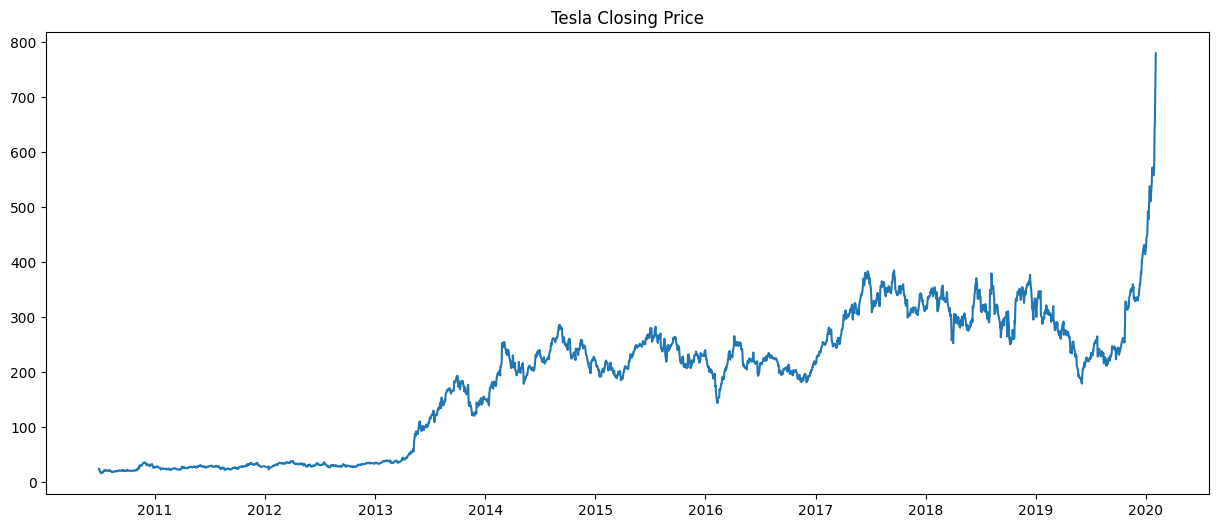

In [18]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'])

plt.title("Tesla Closing Price")
plt.show()

Volume Analysis

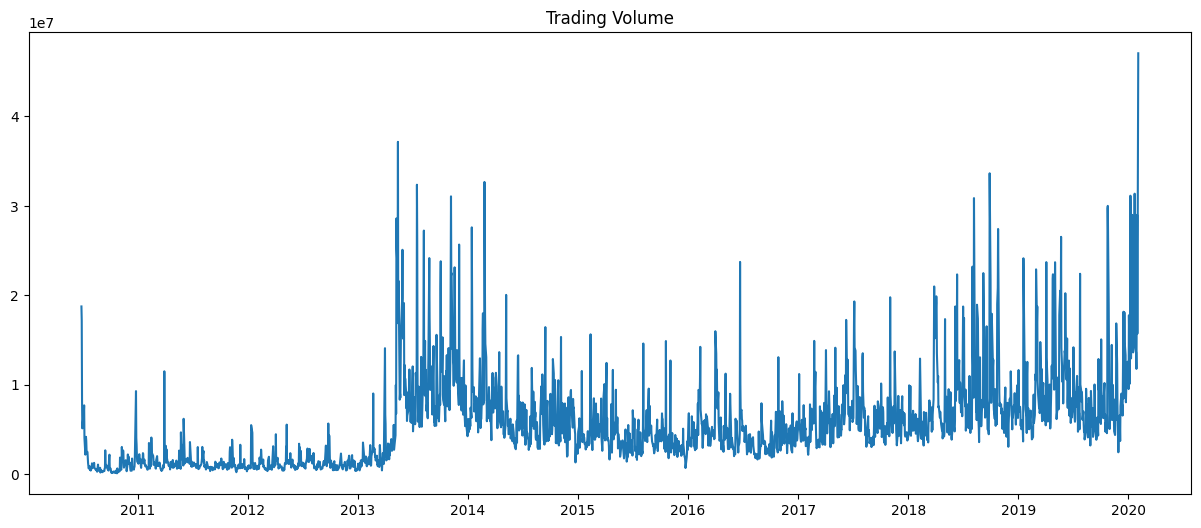

In [19]:
plt.figure(figsize=(15,6))

plt.plot(df['Volume'])

plt.title("Trading Volume")
plt.show()

Distribution

<Axes: xlabel='Close', ylabel='Count'>

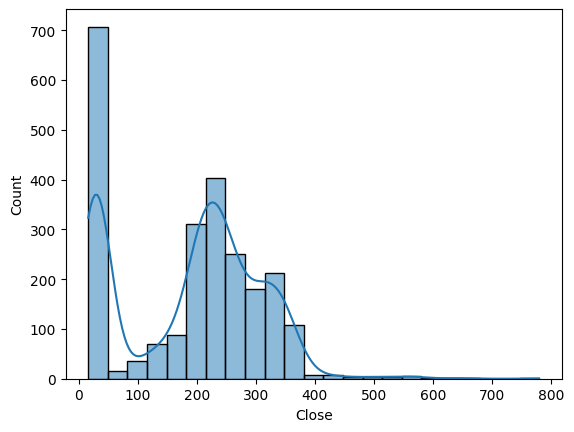

In [20]:
sns.histplot(df['Close'], kde=True)

Correlation Heatmap

<Axes: >

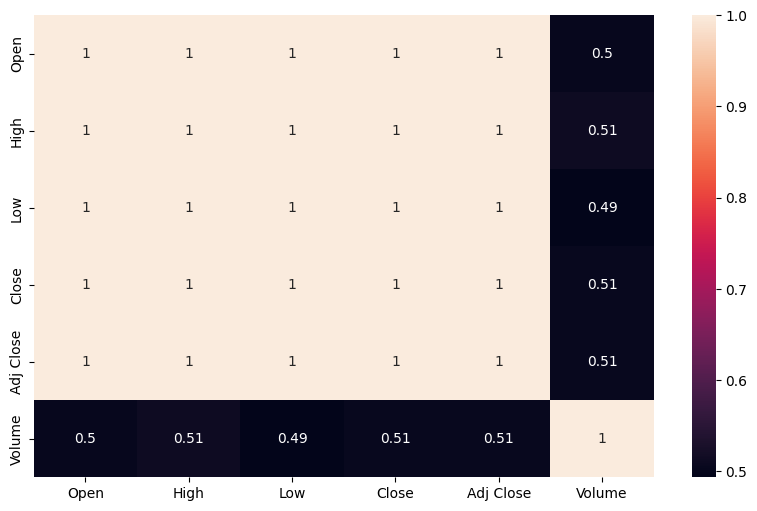

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True)

Step 8:

```
# This is formatted as code
```

Feature Engineering

In [22]:
data = df[['Close']]

Moving Average 50

In [23]:
df['MA50'] = df['Close'].rolling(50).mean()

Moving Average 200

In [24]:
df['MA200'] = df['Close'].rolling(200).mean()

Visualization

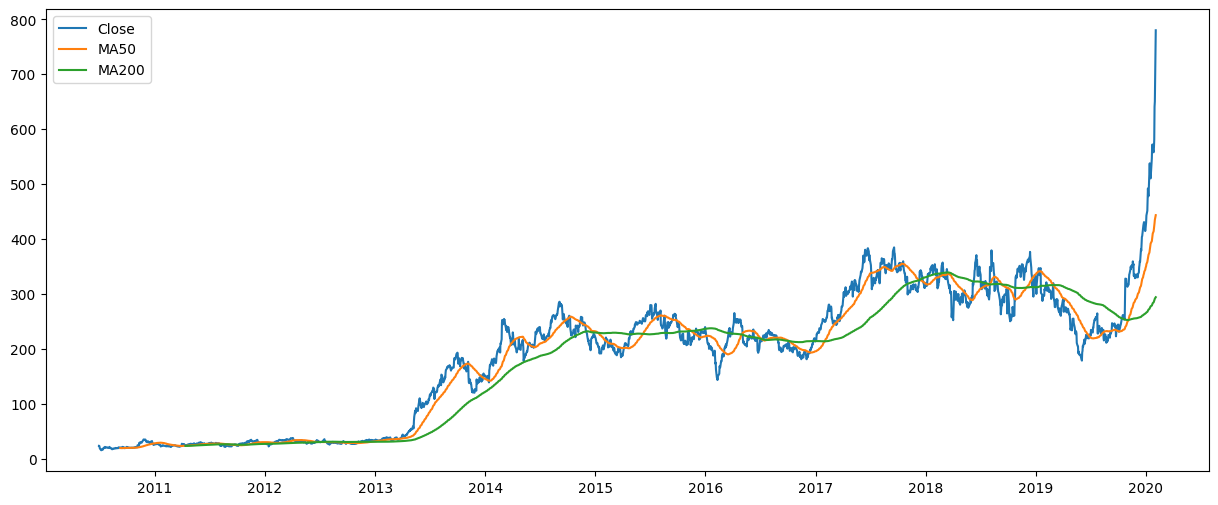

In [25]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'])
plt.plot(df['MA50'])
plt.plot(df['MA200'])

plt.legend(['Close','MA50','MA200'])

Step 9: Scaling

In [26]:
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(data)

Step 10: Create Sequences

In [27]:
def create_dataset(dataset, lookback=60):

    X = []
    y = []

    for i in range(lookback, len(dataset)):
        X.append(dataset[i-lookback:i,0])
        y.append(dataset[i,0])

    return np.array(X), np.array(y)

Generate data

In [28]:
X,y = create_dataset(scaled_data)

Reshape

In [29]:
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

Step 11: Train-Test Split

In [30]:
train_size = int(len(X)*0.8)

In [31]:
X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

Step 12: Build SimpleRNN Model

In [32]:
rnn_model = Sequential()

In [33]:
rnn_model.add(
    SimpleRNN(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

rnn_model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [34]:
rnn_model.add(
    SimpleRNN(50)
)

rnn_model.add(Dropout(0.2))

In [35]:
rnn_model.add(Dense(1))

In [36]:
rnn_model.compile(
    optimizer='adam',
    loss='mse'
)

Step 13: Train RNN

In [37]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [38]:
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 0.0343 - val_loss: 0.0011
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0091 - val_loss: 0.0033
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0060 - val_loss: 0.0024
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0040 - val_loss: 0.0012
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0033 - val_loss: 0.0012
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0020 - val_loss: 0.0011
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0016 - val_loss: 4.5035e-04
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0013 - val_loss: 5.8161e-04
Epoch 11/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0011 - val_loss: 5.3000e-04
Epoch 12/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

Step 14: Evaluate RNN

In [39]:
rnn_pred = rnn_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


In [40]:
rnn_pred = scaler.inverse_transform(rnn_pred)

y_actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

In [41]:
mse_rnn = mean_squared_error(
    y_actual,
    rnn_pred
)

rmse_rnn = np.sqrt(mse_rnn)

mae_rnn = mean_absolute_error(
    y_actual,
    rnn_pred
)

Step 15: Build LSTM Model

In [42]:
lstm_model = Sequential()

In [43]:
lstm_model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

lstm_model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
lstm_model.add(
    LSTM(50)
)

lstm_model.add(Dropout(0.2))

In [45]:
lstm_model.add(Dense(1))

In [46]:
lstm_model.compile(
    optimizer='adam',
    loss='mse'
)

Step 16: Train LSTM

In [47]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0037 - val_loss: 6.9336e-04
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 5.5800e-04 - val_loss: 6.3589e-04
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 4.9883e-04 - val_loss: 0.0022
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 5.4777e-04 - val_loss: 7.2135e-04
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 4.9462e-04 - val_loss: 3.6428e-04
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 4.3078e-04 - val_loss: 7.8961e-04
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 4.5013e-04 - val_loss: 0.0012
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 3.8252e-04 - val_loss: 9.5010e-04
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 3.9548e-04 - val_loss: 6.6536e-04
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - loss: 3.9383e-04 - val_loss: 8.7459e-04


Step 17: Evaluate LSTM

In [48]:
lstm_pred = lstm_model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


In [49]:
lstm_pred = scaler.inverse_transform(
    lstm_pred
)

In [50]:
mse_lstm = mean_squared_error(
    y_actual,
    lstm_pred
)

rmse_lstm = np.sqrt(mse_lstm)

mae_lstm = mean_absolute_error(
    y_actual,
    lstm_pred
)

Step 18: Compare Models

In [51]:
comparison = pd.DataFrame({

'Model':['SimpleRNN','LSTM'],

'MSE':[mse_rnn,mse_lstm],

'RMSE':[rmse_rnn,rmse_lstm],

'MAE':[mae_rnn,mae_lstm]

})

In [52]:
comparison

,Model,MSE,RMSE,MAE
0,SimpleRNN,362.156512,19.030410,11.629305
1,LSTM,1290.545020,35.924156,23.919265


Step 19: Actual vs Predicted Graph

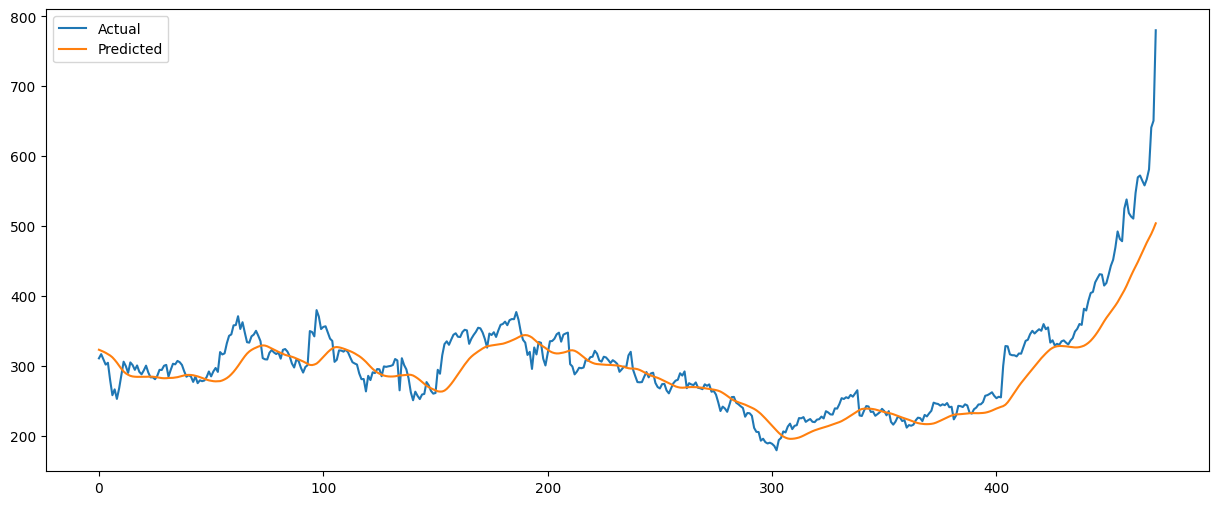

In [53]:
plt.figure(figsize=(15,6))

plt.plot(y_actual)

plt.plot(lstm_pred)

plt.legend([
    "Actual",
    "Predicted"
])

Step 20: 5-Day Prediction

Create 5-Day Dataset

In [54]:
def create_dataset_5day(dataset, lookback=60):

    X = []
    y = []

    for i in range(lookback, len(dataset)-5):
        X.append(dataset[i-lookback:i, 0])
        y.append(dataset[i+5, 0])

    return np.array(X), np.array(y)

X_5, y_5 = create_dataset_5day(scaled_data)

Reshape Data

In [55]:
X_5 = X_5.reshape(X_5.shape[0], X_5.shape[1], 1)

Train-Test Split

In [56]:
train_size = int(len(X_5) * 0.8)

X_train_5 = X_5[:train_size]
X_test_5 = X_5[train_size:]

y_train_5 = y_5[:train_size]
y_test_5 = y_5[train_size:]

Train LSTM Model

In [57]:
lstm_model_5 = Sequential()

lstm_model_5.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
lstm_model_5.add(Dropout(0.2))

lstm_model_5.add(LSTM(50))
lstm_model_5.add(Dropout(0.2))

lstm_model_5.add(Dense(1))

lstm_model_5.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fit Model

In [58]:
history_lstm_5 = lstm_model_5.fit(
    X_train_5,
    y_train_5,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - loss: 0.0051 - val_loss: 7.9414e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 8.6893e-04 - val_loss: 7.3433e-04
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 7.5600e-04 - val_loss: 0.0015
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - loss: 6.5783e-04 - val_loss: 7.4476e-04
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 6.9463e-04 - val_loss: 6.5003e-04
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 5.9864e-04 - val_loss: 9.8326e-04
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 6.0351e-04 - val_loss: 7.4565e-04
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 5.8265e-04 - val_loss: 8.4829e-04
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - loss: 5.8609e-04 - val_loss: 7.4442e-04
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 5.5705e-04 - val_loss: 0.0017


Predict & Evaluate

In [59]:
pred_5 = lstm_model_5.predict(X_test_5)

pred_5 = scaler.inverse_transform(pred_5)

actual_5 = scaler.inverse_transform(
    y_test_5.reshape(-1,1)
)

mse_5 = mean_squared_error(actual_5, pred_5)
rmse_5 = np.sqrt(mse_5)
mae_5 = mean_absolute_error(actual_5, pred_5)

print("MSE :", mse_5)
print("RMSE:", rmse_5)
print("MAE :", mae_5)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
MSE : 1713.1182916098815
RMSE: 41.38983319137541
MAE : 30.71393548891571


Visualization

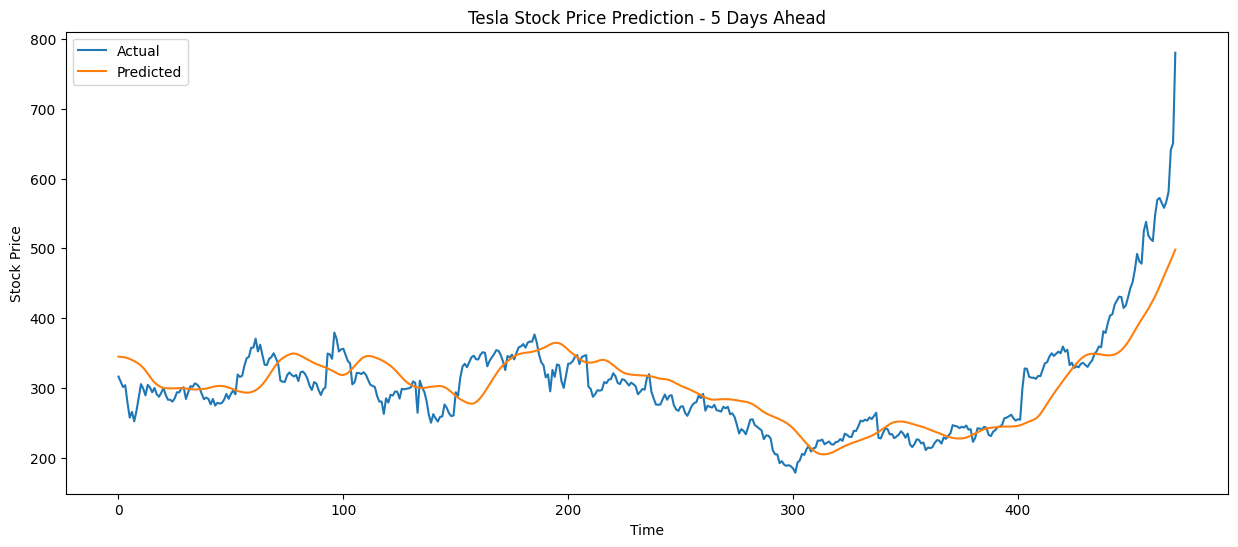

In [60]:
plt.figure(figsize=(15,6))

plt.plot(actual_5, label='Actual')
plt.plot(pred_5, label='Predicted')

plt.title('Tesla Stock Price Prediction - 5 Days Ahead')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()

plt.show()

Step 21: 10-Day Ahead Stock Price Prediction

Create 10-Day Dataset

In [61]:
def create_dataset_10day(dataset, lookback=60):

    X = []
    y = []

    for i in range(lookback, len(dataset)-10):
        X.append(dataset[i-lookback:i, 0])
        y.append(dataset[i+10, 0])

    return np.array(X), np.array(y)

X_10, y_10 = create_dataset_10day(scaled_data)

Reshape Data

In [62]:
X_10 = X_10.reshape(X_10.shape[0], X_10.shape[1], 1)

Train-Test Split

In [63]:
train_size = int(len(X_10) * 0.8)

X_train_10 = X_10[:train_size]
X_test_10 = X_10[train_size:]

y_train_10 = y_10[:train_size]
y_test_10 = y_10[train_size:]

Build LSTM Model

In [64]:
lstm_model_10 = Sequential()

lstm_model_10.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(60,1)
    )
)

lstm_model_10.add(Dropout(0.2))

lstm_model_10.add(LSTM(50))

lstm_model_10.add(Dropout(0.2))

lstm_model_10.add(Dense(1))

lstm_model_10.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Train Model

In [65]:
history_lstm_10 = lstm_model_10.fit(
    X_train_10,
    y_train_10,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 0.0050 - val_loss: 9.3619e-04
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - loss: 0.0010 - val_loss: 0.0022
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - loss: 8.6943e-04 - val_loss: 0.0014
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 8.2327e-04 - val_loss: 0.0012
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 7.4392e-04 - val_loss: 0.0013
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 7.1106e-04 - val_loss: 0.0016
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - loss: 7.5360e-04 - val_loss: 0.0021
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - loss: 7.0983e-04 - val_loss: 0.0017
Epoch 9/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 7.3421e-04 - val_loss: 0.0019
Epoch 10/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - loss: 6.7898e-04 - val_loss: 0.0033


Prediction

In [66]:
pred_10 = lstm_model_10.predict(X_test_10)

pred_10 = scaler.inverse_transform(pred_10)

actual_10 = scaler.inverse_transform(
    y_test_10.reshape(-1,1)
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


Evaluation

In [67]:
mse_10 = mean_squared_error(actual_10, pred_10)

rmse_10 = np.sqrt(mse_10)

mae_10 = mean_absolute_error(actual_10, pred_10)

print("MSE :", mse_10)
print("RMSE:", rmse_10)
print("MAE :", mae_10)

MSE : 2335.185724308058
RMSE: 48.32375941819984
MAE : 33.44643903021734


Visualization

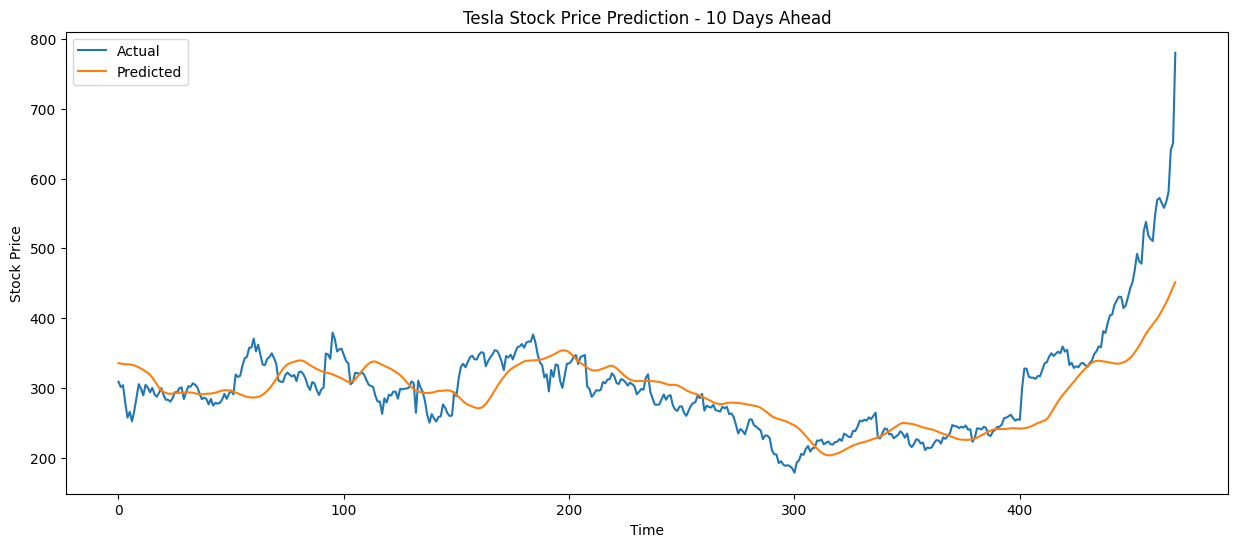

In [68]:
plt.figure(figsize=(15,6))

plt.plot(actual_10, label='Actual')

plt.plot(pred_10, label='Predicted')

plt.title('Tesla Stock Price Prediction - 10 Days Ahead')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.show()

Step 22: Hyperparameter Tuning

In [69]:
!pip install keras-tuner



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.2 MB/s eta 0:00:00


Import

In [70]:
import keras_tuner as kt

Create Model Function

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

def build_model(hp):

    model = Sequential()

    model.add(
        LSTM(
            units=hp.Int('units', 32, 128, step=32),
            input_shape=(60,1)
        )
    )

    model.add(
        Dropout(
            hp.Float(
                'dropout',
                0.1,
                0.5,
                step=0.1
            )
        )
    )

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(
            learning_rate=hp.Choice(
                'learning_rate',
                [0.001,0.0001]
            )
        ),
        loss='mse'
    )

    return model

 Search

In [72]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    directory='tuner_dir',
    project_name='tesla_lstm'
)

tuner.search(
    X_train,
    y_train,
    epochs=20,
    validation_split=0.2
)

Trial 10 Complete [00h 00m 28s]
val_loss: 0.0005737437750212848

Best val_loss So Far: 0.00021858546824660152
Total elapsed time: 00h 08m 11s


Best Parameters:

In [73]:
best_hps = tuner.get_best_hyperparameters(1)[0]

print("Units:", best_hps.get('units'))
print("Dropout:", best_hps.get('dropout'))
print("Learning Rate:", best_hps.get('learning_rate'))

Units: 128
Dropout: 0.2
Learning Rate: 0.001


Step 23: Build Optimized LSTM Model

In [74]:
optimized_lstm = Sequential()

optimized_lstm.add(
    LSTM(
        units=best_hps.get('units'),
        input_shape=(60,1)
    )
)

optimized_lstm.add(
    Dropout(
        best_hps.get('dropout')
    )
)

optimized_lstm.add(Dense(1))

optimized_lstm.compile(
    optimizer=Adam(
        learning_rate=best_hps.get('learning_rate')
    ),
    loss='mse'
)

Step 24: Train Optimized Model

In [75]:
history_optimized = optimized_lstm.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - loss: 0.0039 - val_loss: 6.8365e-04
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 154ms/step - loss: 3.4885e-04 - val_loss: 3.2894e-04
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 3.2191e-04 - val_loss: 3.1628e-04
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 2.5660e-04 - val_loss: 3.0410e-04
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - loss: 2.5686e-04 - val_loss: 3.0943e-04
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 2.3578e-04 - val_loss: 3.0019e-04
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 2.4529e-04 - val_loss: 2.7577e-04
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 2.2044e-04 - val_loss: 3.6901e-04
Epoch 9/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 2.3785e-04 - val_loss: 2.8410e-04
Epoch 10/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 2.0482e-04 - val_loss: 3.3809e-04


Step 25: Make Predictions

In [76]:
optimized_pred = optimized_lstm.predict(X_test)

optimized_pred = scaler.inverse_transform(
    optimized_pred
)

actual = scaler.inverse_transform(
    y_test.reshape(-1,1)
)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


Step 26: Evaluate Optimized Model

In [77]:
mse_opt = mean_squared_error(
    actual,
    optimized_pred
)

rmse_opt = np.sqrt(mse_opt)

mae_opt = mean_absolute_error(
    actual,
    optimized_pred
)

print("MSE :", mse_opt)
print("RMSE:", rmse_opt)
print("MAE :", mae_opt)

MSE : 700.215681114014
RMSE: 26.46158878665478
MAE : 20.38312978164311


Step 27: Compare All Models

In [78]:
comparison_models = pd.DataFrame({

    'Model':[
        'SimpleRNN',
        'LSTM',
        'Optimized LSTM'
    ],

    'MSE':[
        mse_rnn,
        mse_lstm,
        mse_opt
    ],

    'RMSE':[
        rmse_rnn,
        rmse_lstm,
        rmse_opt
    ],

    'MAE':[
        mae_rnn,
        mae_lstm,
        mae_opt
    ]

})

comparison_models

,Model,MSE,RMSE,MAE
0,SimpleRNN,362.156512,19.030410,11.629305
1,LSTM,1290.545020,35.924156,23.919265
2,Optimized LSTM,700.215681,26.461589,20.383130


Step 28: Plot Actual vs Predicted

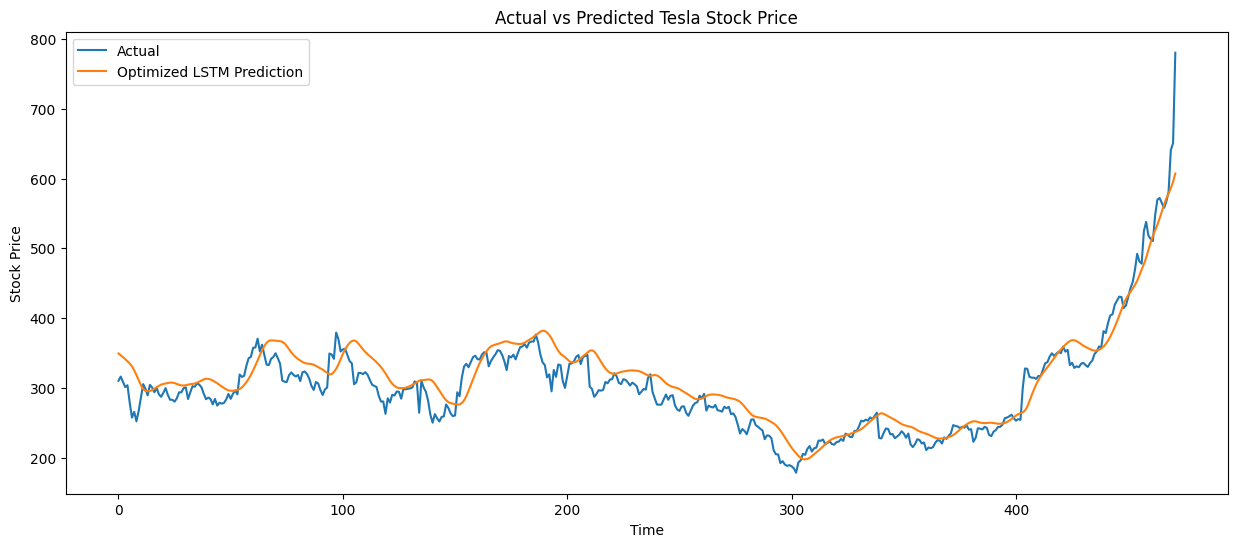

In [79]:
plt.figure(figsize=(15,6))

plt.plot(actual, label='Actual')

plt.plot(
    optimized_pred,
    label='Optimized LSTM Prediction'
)

plt.title('Actual vs Predicted Tesla Stock Price')

plt.xlabel('Time')

plt.ylabel('Stock Price')

plt.legend()

plt.show()

Step 29: Save the Best Model

In [80]:
optimized_lstm.save(
    "best_lstm_model.keras"
)

Step 30: Save the Scaler

In [81]:
import joblib

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

Step 31: Forecast Horizon Comparison

In [82]:
forecast_comparison = pd.DataFrame({

    'Forecast Horizon':[
        '1 Day',
        '5 Days',
        '10 Days'
    ],

    'MSE':[
        mse_lstm,
        mse_5,
        mse_10
    ],

    'RMSE':[
        rmse_lstm,
        rmse_5,
        rmse_10
    ],

    'MAE':[
        mae_lstm,
        mae_5,
        mae_10
    ]

})

forecast_comparison

,Forecast Horizon,MSE,RMSE,MAE
0,1 Day,1290.545020,35.924156,23.919265
1,5 Days,1713.118292,41.389833,30.713935
2,10 Days,2335.185724,48.323759,33.446439


Step 32: Training vs Validation Loss Plot

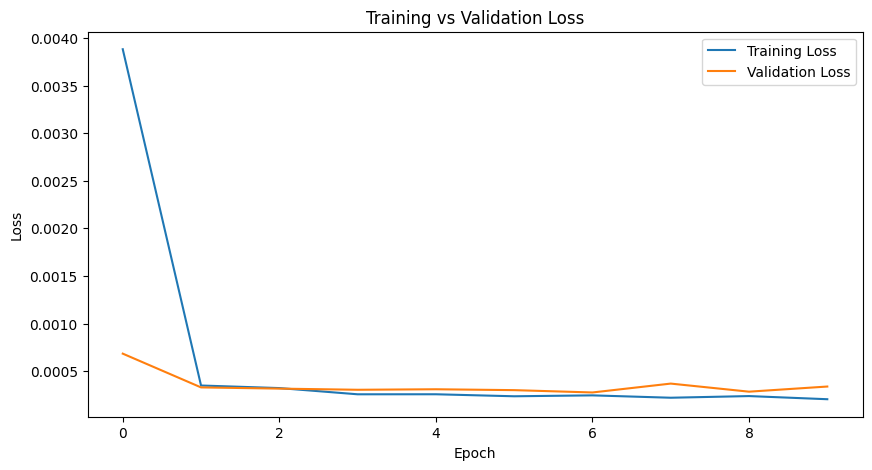

In [83]:
plt.figure(figsize=(10,5))

plt.plot(
    history_optimized.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_optimized.history['val_loss'],
    label='Validation Loss'
)

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

Step 33: Business Insights
. LSTM outperformed SimpleRNN in forecasting Tesla stock prices.

2. Hyperparameter tuning improved model performance.

3. Short-term forecasts were more accurate than long-term forecasts.

4. The model can assist investors in identifying potential stock trends.

5. Such predictive models can support portfolio management and risk assessment.

Step 34: Conclusion
The objective of this project was to predict Tesla stock prices using deep learning techniques.

After preprocessing the data and creating time-series sequences, SimpleRNN and LSTM models were developed and evaluated.

The LSTM model achieved better performance due to its ability to capture long-term dependencies in stock price movements.

Hyperparameter tuning further improved model accuracy. The forecasting performance was evaluated for 1-day, 5-day, and 10-day prediction horizons.

The project demonstrates the effectiveness of deep learning approaches for financial time-series forecasting.

Step 35: Future Scope
1. Incorporate Tesla news sentiment analysis.

2. Include macroeconomic indicators such as inflation and interest rates.

3. Compare performance with GRU and Transformer architectures.

4. Use real-time stock market APIs for live predictions.

5. Deploy a real-time forecasting dashboard using Streamlit.

In [84]:
import os

os.makedirs("Tesla_Stock_App", exist_ok=True)

In [85]:
optimized_lstm.save(
    "Tesla_Stock_App/best_lstm_model.keras"
)

joblib.dump(
    scaler,
    "Tesla_Stock_App/scaler.pkl"
)

['Tesla_Stock_App/scaler.pkl']

In [89]:
os.makedirs("Tesla_Stock_App", exist_ok=True)
import os

print(os.getcwd())

/content
